In [1]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Model Architecture
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10) 

# 3. Load weights to CPU first (Safe Method)
# CHANGE IS HERE: Force map_location='cpu'
state_dict = torch.load("tomato_disease_model.pth", map_location=torch.device('cpu'))

# 4. Load the state dict into the model
model.load_state_dict(state_dict)

# 5. Move the whole model to GPU
model = model.to(device)
model.eval()

print(f"Model loaded successfully on {device}")

d:\Retesh Halder\AI-ML\AI-ML Projects\Tomato Leaf Disease Detection_1\gpu_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Retesh Halder\AI-ML\AI-ML Projects\Tomato Leaf Disease Detection_1\gpu_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully on cuda


Predicted Disease: Tomato___Tomato_Yellow_Leaf_Curl_Virus


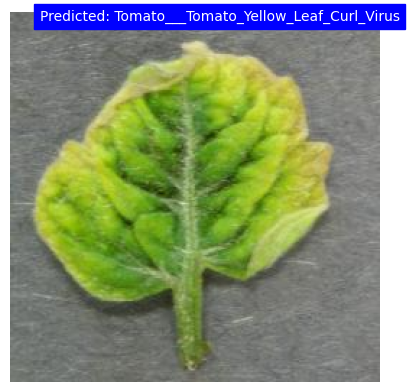

In [27]:
from PIL import Image                  
from torchvision import transforms     
import matplotlib.pyplot as plt
import numpy as np
import torch

# Define path
image_path = r'D:\Retesh Halder\AI-ML\AI-ML Projects\Tomato Leaf Disease Detection_1\test data\Tomato___Tomato_Yellow_Leaf_Curl_Virus\f6ce32e5-da3a-40a9-a3b8-47c1325991f5___UF.GRC_YLCV_Lab 02878.JPG'
# Define Preprocess
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Process image
input_tensor = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = model(input_tensor)

pred_idx = torch.argmax(output, dim=1).item()

class_names = [
'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy'
]

predicted_disease = class_names[pred_idx]
print(f"Predicted Disease: {predicted_disease}")

# Visualization
plt.imshow(np.array(Image.open(image_path).convert("RGB")))
plt.axis('off')
plt.text(20,5, f'Predicted: {predicted_disease}', color='white', fontsize=10, backgroundcolor='blue')
plt.show()